# Berry curvature, Chern numbers and Z2 invariants

Everything here is built from one primitive: $\langle u_{m\mathbf k}|S|u_{n\mathbf k'}
\rangle$, the overlap of the occupied manifolds at neighbouring k-points. Not from a
derivative of the eigenproblem — because a determinant of overlaps is blind to the
unitary mixing a degenerate eigensolver leaves behind, *and* because the
Fukui-Hatsugai-Suzuki lattice sum is an **exact integer** on any mesh where a Riemann sum
of a pointwise curvature is not.

**Two things bite in a plane-wave code and both are silent:** neighbouring k-points do not
share a G-sphere, so coefficients are aligned by Miller index; and the wrap at the zone
edge is a *shift* of that index, $u_{k+b}(G) = u_k(G+b)$.

The curvature and its integral, and the lattice form that makes the integral exact:

$$\Omega_{n}(\mathbf k) = i\,\nabla_{\mathbf k} \times
   \langle u_{n\mathbf k}|\nabla_{\mathbf k} u_{n\mathbf k}\rangle,
\qquad
C = \frac{1}{2\pi}\int_{\rm BZ} \Omega(\mathbf k)\; d^2k \in \mathbb{Z}$$

$$C = \frac{1}{2\pi}\sum_{\square}
  \arg \Big[
   \det M^{(\mathbf k,\mathbf k+\mathbf b_1)}\;
   \det M^{(\mathbf k+\mathbf b_1,\mathbf k+\mathbf b_1+\mathbf b_2)}\;
   \det M^{(\cdots)}\;\det M^{(\cdots)} \Big],
\qquad
M^{(\mathbf k,\mathbf k')}_{mn} =
  \langle u_{m\mathbf k}|\hat S|u_{n\mathbf k'}\rangle$$

The second is Fukui-Hatsugai-Suzuki: a sum of plaquette phases, each in $(-\pi,\pi]$,
which is an **exact integer on any mesh** where a Riemann sum of the first is not.

Phase P16.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from pypresso import Calculator
from pypresso.system.symmetry import find_symmetries
from pypresso.topology import (ModelSource, chern_number, plane_mesh, trim_points,
                               z2_invariant, z2_invariant_3d)
from pypresso.topology.parity import inversion_centre, parity_eigenvalues
from pypresso.workflows.topology import DFTSource, run_berry_curvature

REPO = Path.cwd().parent
PSEUDO, CASES = REPO / "tests" / "data" / "pseudo", REPO / "tests" / "data" / "qe"
sys.path.insert(0, str(REPO))
plt.rcParams.update({"figure.dpi": 120, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.3, "figure.autolayout": True})

silicon = Calculator.from_file(CASES / "si2-us.in", pseudo_dir=PSEUDO,
                               announce=False, conv_thr=1e-10)
system, pseudos = silicon.system, silicon.pseudos
si = silicon.get_scf()
source = DFTSource(system=system, pseudos=pseudos, density=si.density, nocc=4)

# The zone-edge wrap, measured: k = 0.4 -> 0.5 directly, and the same step taken as
# 0.4 -> -0.5 + b1, with and without the Miller-index shift that makes them the same.
direct = source.states(np.array([[0.4, 0, 0], [0.5, 0, 0]]))
through = source.states(np.array([[0.4, 0, 0], [-0.5, 0, 0]]))
print("|det M|  k = 0.4 -> 0.5   directly     %.10f"
      % abs(np.linalg.det(np.asarray(direct.overlap(0, 1, None)))))
print("|det M|  k = 0.4 -> -0.5  through b1   %.10f"
      % abs(np.linalg.det(np.asarray(through.overlap(0, 1, [1, 0, 0])))))
print("|det M|  k = 0.4 -> -0.5  no wrap      %.10f   <- wrong, and smooth"
      % abs(np.linalg.det(np.asarray(through.overlap(0, 1, None)))))

|det M|  k = 0.4 -> 0.5   directly     0.9904014550
|det M|  k = 0.4 -> -0.5  through b1   0.9904014650
|det M|  k = 0.4 -> -0.5  no wrap      0.0091756299   <- wrong, and smooth


## The Chern number is an integer, not nearly one

The Haldane model, where the answer is known. The lattice sum returns 1 to fifteen
decimals on a 6x6 mesh; the velocity-operator (Kubo) route, which is `jacfwd` of $H(k)$
and gives a smooth pointwise $\Omega(k)$, is still 1e-3 off on 24x24. Both are
registered — one for the invariant, one for the picture.

    mesh            C (lattice)   max plaquette phase     C (kubo)


  6x6        -1.000000000000000                0.6901    -1.008575


 12x12       -1.000000000000000                0.1983    -1.000017


 24x24       -1.000000000000000                0.0532    -1.000000


trivial (mass 1.5), 12x12:  C = -0.000000000000000


Text(0.5, 0.98, 'Haldane model: the same curvature, two constructions')

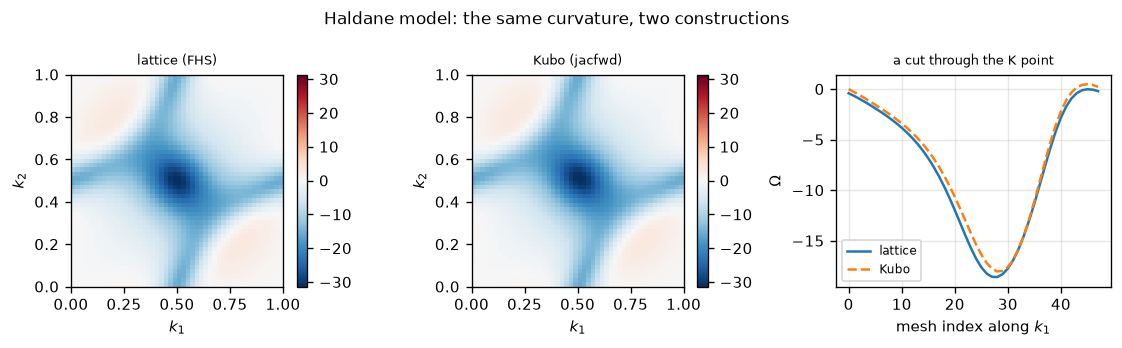

In [2]:
from tests.models import haldane, kane_mele, kane_mele_critical_mass

topological = ModelSource(hamiltonian=haldane(t2=0.2, mass=0.0), nocc=1)
trivial = ModelSource(hamiltonian=haldane(t2=0.2, mass=1.5), nocc=1)

print("%8s %22s %21s %12s" % ("mesh", "C (lattice)", "max plaquette phase", "C (kubo)"))
for n in (6, 12, 24):
    lattice = chern_number(topological, shape=(n, n))
    kubo = chern_number(topological, shape=(n, n), method="kubo", nocc=1)
    print("%3dx%-4d %22.15f %21.4f %12.6f"
          % (n, n, lattice.chern_number, lattice.max_flux, kubo.chern_number))
print("trivial (mass 1.5), 12x12:  C = %.15f"
      % chern_number(trivial, shape=(12, 12)).chern_number)

lattice = chern_number(topological, shape=(48, 48))
kubo = chern_number(topological, shape=(48, 48), method="kubo", nocc=1)
scale = np.max(np.abs(lattice.curvature))
fig, axes = plt.subplots(1, 3, figsize=(9.5, 2.9))
for ax, field, title in ((axes[0], lattice.curvature, "lattice (FHS)"),
                         (axes[1], kubo.curvature, "Kubo (jacfwd)")):
    image = ax.imshow(field.T, origin="lower", extent=[0, 1, 0, 1], cmap="RdBu_r",
                      vmin=-scale, vmax=scale)
    ax.set_title(title, fontsize=8); ax.set_xlabel("$k_1$"); ax.set_ylabel("$k_2$")
    ax.grid(False); fig.colorbar(image, ax=ax, fraction=0.046)
axes[2].plot(lattice.curvature[:, 16], label="lattice")
axes[2].plot(kubo.curvature[:, 16], "--", label="Kubo")
axes[2].set_title("a cut through the K point", fontsize=8)
axes[2].set_xlabel("mesh index along $k_1$"); axes[2].set_ylabel(r"$\Omega$")
axes[2].legend(fontsize=7)
fig.suptitle("Haldane model: the same curvature, two constructions", fontsize=10)

## Z2 by the flow of Wannier charge centres

With time reversal the Chern number vanishes and what is left is a $\mathbb{Z}_2$. Pump
one half of the zone and watch the Wannier centres of the occupied bands: in the
topological phase they switch partners, so any horizontal reference line is crossed an
odd number of times. `gap_step` — how far the largest-gap reference line moves in one
step — is this route's own diagnostic, and it is the number to read before believing the
integer.

mass = 0.1299 = 0.5 m_c   ->   z2 = 1


mass = 0.3897 = 1.5 m_c   ->   z2 = 0


Text(0.5, 0.98, 'Kane-Mele: the centres switch partners only in the topological phase')

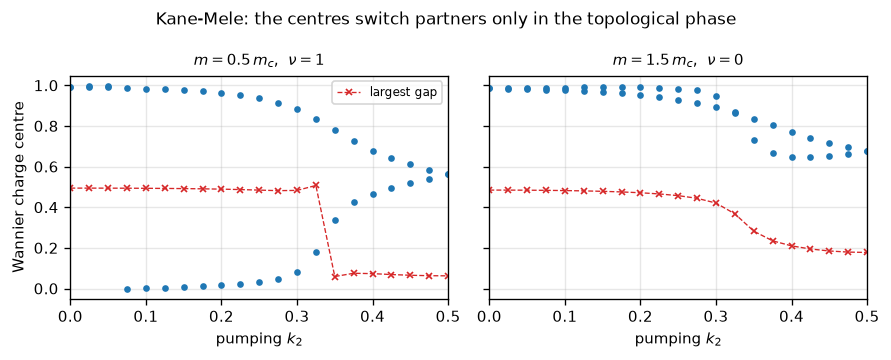

In [3]:
soc = 0.05
critical = kane_mele_critical_mass(soc)
flows = {}
for factor in (0.5, 1.5):
    flows[factor] = z2_invariant(
        ModelSource(hamiltonian=kane_mele(soc=soc, mass=factor * critical), nocc=2),
        nloop=41, npump=21)
    print("mass = %.4f = %g m_c   ->   z2 = %d"
          % (factor * critical, factor, flows[factor].z2))

fig, axes = plt.subplots(1, 2, figsize=(7.5, 3.0), sharey=True)
for ax, (factor, flow) in zip(axes, sorted(flows.items())):
    for branch in range(flow.centers.shape[1]):
        ax.plot(flow.pump, flow.centers_fractional[:, branch], "o", ms=3, color="C0")
    ax.plot(flow.pump, (flow.gap_center / (2 * np.pi)) % 1.0, "x--", ms=4, lw=0.8,
            color="C3", label="largest gap")
    ax.set_title(r"$m = %g\,m_c$,  $\nu = %d$" % (factor, flow.z2), fontsize=9)
    ax.set_xlabel("pumping $k_2$"); ax.set_xlim(0, 0.5)
axes[0].set_ylabel("Wannier charge centre"); axes[0].legend(fontsize=7)
fig.suptitle("Kane-Mele: the centres switch partners only in the topological phase",
             fontsize=10)

## A second, independent route: parities at the TRIM

Where the crystal has an inversion centre, Fu and Kane's product of parity eigenvalues
over the time-reversal-invariant momenta gives the same invariant from **eight
diagonalisations and no mesh**. Running both wherever both apply is the check — first on
a 3D lattice Dirac model whose four phases are known in closed form, then on silicon's
real Kohn-Sham states.

In [4]:
from tests.models import (WILSON_FERMION_INVERSION, wilson_fermion_3d,
                          wilson_fermion_indices)

print("%6s %14s %10s %10s" % ("m", "closed form", "parity", "Wilson"))
for mass in (-4.0, -2.0, 0.0, 2.0):
    model = ModelSource(hamiltonian=wilson_fermion_3d(mass), nocc=2,
                        inversion=WILSON_FERMION_INVERSION)
    exact = wilson_fermion_indices(mass)
    print("%6.1f %14s %10s %10s"
          % (mass, "(%d; %s)" % (exact[0], "".join(str(x) for x in exact[1])),
             z2_invariant_3d(model, method="parity"),
             z2_invariant_3d(model, method="wilson", nloop=16, npump=9)))

centre = inversion_centre(find_symmetries(system.cell, system.structure))
points = trim_points(3)
si_trim = source.states(points, keep_projectors=True)
product = 1
print("\nsilicon, on Kohn-Sham states:")
for index, point in enumerate(points):
    matrix = np.asarray(si_trim.parity_matrix(index, centre))
    values = parity_eigenvalues(matrix)
    product *= int(np.prod(values))
    print("  %16s  parities %s  delta = %+d"
          % ("(" + ", ".join("%.1f" % x for x in point) + ")",
             values.astype(int), int(np.prod(values))))
print("  product over the eight TRIM = %+d   ->   nu0 = %d"
      % (product, 0 if product == 1 else 1))

curvature = silicon.get_berry_curvature(shape=(6, 6), nocc=4)
print("\nsilicon's Berry curvature (6x6 plane at k3 = 0): Chern number %.1e, "
      "largest plaquette phase %.1e"
      % (curvature.chern_number, curvature.max_flux))

     m    closed form     parity     Wilson


  -4.0       (0; 000)   (0; 000)   (0; 000)


  -2.0       (1; 000)   (1; 000)   (1; 000)


   0.0       (0; 111)   (0; 111)   (0; 111)


   2.0       (1; 111)   (1; 111)   (1; 111)



silicon, on Kohn-Sham states:


   (0.0, 0.0, 0.0)  parities [1 1 1 1]  delta = +1
   (0.0, 0.0, 0.5)  parities [-1 -1 -1  1]  delta = -1
   (0.0, 0.5, 0.0)  parities [-1 -1 -1  1]  delta = -1
   (0.0, 0.5, 0.5)  parities [-1 -1  1  1]  delta = +1
   (0.5, 0.0, 0.0)  parities [-1 -1 -1  1]  delta = -1
   (0.5, 0.0, 0.5)  parities [-1 -1  1  1]  delta = +1
   (0.5, 0.5, 0.0)  parities [-1 -1  1  1]  delta = +1
   (0.5, 0.5, 0.5)  parities [-1  1  1  1]  delta = -1
  product over the eight TRIM = +1   ->   nu0 = 0



silicon's Berry curvature (6x6 plane at k3 = 0): Chern number 2.7e-17, largest plaquette phase 8.7e-08


Silicon is inversion-symmetric *and* time-reversal-symmetric, so its curvature vanishes
pointwise rather than on average — the 6x6 plane above says so — and its parity product
makes it the trivial insulator it is.

## Bismuthene, and what to do when the two routes disagree

The hardest case this subpackage handles — two-component spinors, an ultrasoft *fully
relativistic* dataset, PBE — is **not run here**, because an SCF and a topology run each
build their own gigabyte-scale `Calculation` and doing both in one kernel peaks at
7.8 GB. Measured in its own process on `bismuthene-soc-small.in` (`tests/data/qe/`, and
`tests/regression/test_topology.py` carries it):

```
SCF, 7 irreducible k-points          -295.610317532 Ry     281 s   4.24 GB
q^(s1s2)_ij(b -> 0) against qq_so     1.0e-16   (scale 0.1382)
<u_m|S|u_n> - delta_mn                4.4e-15   (30 spinor bands)
parity, 4 TRIM: nu = 0                delta = -1 at all four     133 s
Wilson, 12 x 7 mesh: z2 = 1           gap_step = 0.197           786 s   4.53 GB
```

The two disagree, which is the interesting outcome rather than an embarrassing one. **The
parity route has no mesh** — four diagonalisations at exact points, parity eigenvalues
coming out $\pm1$ to 1e-6 — and the Wilson route's own diagnostic says its mesh is not
enough: the reference line moves a fifth of the way round the circle in a single pumping
step. Where they disagree, the parity one is the answer.

---
**The detail:** `PLAN.md` §3 P16 — the alignment by Miller index, the zone-edge shift,
ultrasoft $S$ between two k-points being $q_{ij}(b)$ rather than `qq`, and why the
plane-wave velocity operator is refused rather than approximated (it needs
$d(\mathrm{vkb})/dk$, which belongs to P11).
**The tests:** `tests/regression/test_topology.py`, `tests/unit/test_topology_*.py`.